<a href="https://www.kaggle.com/code/sonawanelalitsunil/remote-work-mental-health-ml-35?scriptVersionId=251447163" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mental-health-of-remote-workers/mental_health_remote_workers.csv


## Title:
Remote Work & Mental Health

## Description:
This study explores the mental health impacts of remote work on employees across various industries. With the rise of work-from-home arrangements, many workers report increased feelings of isolation, burnout, and blurred boundaries between personal and professional life. The research highlights key psychological challenges such as anxiety, depression, and work-life imbalance, while also addressing positive aspects like flexibility and reduced commute stress. It aims to understand the correlation between remote work environments and mental well-being, and suggests strategies for employers to promote a healthier, more supportive remote work culture.

In [2]:
df = pd.read_csv('/kaggle/input/mental-health-of-remote-workers/mental_health_remote_workers.csv')

In [3]:
df.head()

,Employee_ID,Name,Age,Gender,Country,Job_Role,Experience_Years,Work_Mode,Hours_Worked_Per_Week,Productivity_Score,Mental_Health_Status,Burnout_Score,Sleep_Hours_Per_Day,Exercise_Frequency,Work_Life_Balance_Rating,Has_Access_To_Therapist,Willing_To_Return_Onsite,Remote_Setup_Satisfaction,Internet_Issues_Frequency,Team_Communication_Effectiveness
0,1,User_1,28,Female,Canada,QA Engineer,5.4,Onsite,45.4,6.6,Poor,44,5.7,Rarely,7.5,True,False,9.9,Sometimes,7.7
1,2,User_2,41,Prefer not to say,Australia,DevOps Engineer,10.5,Remote,40.4,8.4,Good,58,5.1,Daily,8.6,False,True,2.5,Often,9.0
2,3,User_3,36,Male,Germany,UI/UX Designer,11.9,Hybrid,43.6,6.6,Good,78,6.1,Never,6.2,False,False,9.1,Often,7.7
3,4,User_4,32,Prefer not to say,Germany,Product Manager,15.6,Hybrid,41.3,9.0,Moderate,71,5.4,Rarely,8.5,True,True,6.1,Sometimes,8.4
4,5,User_5,29,Male,UK,DevOps Engineer,1.8,Hybrid,42.5,6.9,Poor,69,7.1,Never,6.0,True,True,9.3,Never,4.7


In [4]:
df.tail()

,Employee_ID,Name,Age,Gender,Country,Job_Role,Experience_Years,Work_Mode,Hours_Worked_Per_Week,Productivity_Score,Mental_Health_Status,Burnout_Score,Sleep_Hours_Per_Day,Exercise_Frequency,Work_Life_Balance_Rating,Has_Access_To_Therapist,Willing_To_Return_Onsite,Remote_Setup_Satisfaction,Internet_Issues_Frequency,Team_Communication_Effectiveness
95,96,User_96,29,Male,UK,UI/UX Designer,11.8,Hybrid,36.4,5.3,Good,36,5.0,2-3x/Week,7.2,False,False,7.8,Sometimes,7.7
96,97,User_97,35,Non-binary,Germany,Developer,4.0,Remote,34.3,3.8,Good,78,6.5,Daily,4.9,True,False,8.0,Never,3.3
97,98,User_98,44,Non-binary,Australia,QA Engineer,3.3,Remote,48.4,9.2,Poor,29,7.0,Daily,6.5,False,True,3.6,Often,3.3
98,99,User_99,49,Male,USA,Developer,7.5,Hybrid,43.7,7.2,Poor,20,5.7,2-3x/Week,5.8,False,False,8.9,Often,2.3
99,100,User_100,46,Prefer not to say,USA,Product Manager,2.7,Remote,38.3,7.8,Moderate,83,6.8,Rarely,9.1,True,True,7.7,Never,7.9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Employee_ID                       100 non-null    int64  
 1   Name                              100 non-null    object 
 2   Age                               100 non-null    int64  
 3   Gender                            100 non-null    object 
 4   Country                           100 non-null    object 
 5   Job_Role                          100 non-null    object 
 6   Experience_Years                  100 non-null    float64
 7   Work_Mode                         100 non-null    object 
 8   Hours_Worked_Per_Week             100 non-null    float64
 9   Productivity_Score                100 non-null    float64
 10  Mental_Health_Status              100 non-null    object 
 11  Burnout_Score                     100 non-null    int64  
 12  Sleep_Hou

In [6]:
df.describe()

,Employee_ID,Age,Experience_Years,Hours_Worked_Per_Week,Productivity_Score,Burnout_Score,Sleep_Hours_Per_Day,Work_Life_Balance_Rating,Remote_Setup_Satisfaction,Team_Communication_Effectiveness
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,36.250000,9.444000,42.113000,6.063000,49.550000,6.390000,6.167000,6.150000,6.138000
std,29.011492,8.266245,5.532682,4.535308,1.916154,22.265331,1.366075,2.304368,2.539884,2.305495
min,1.000000,22.000000,1.100000,31.400000,3.100000,10.000000,4.100000,2.000000,2.000000,2.200000
25%,25.750000,29.000000,4.700000,38.550000,4.300000,34.750000,5.275000,4.425000,3.750000,4.000000
50%,50.500000,36.000000,8.700000,42.050000,5.950000,47.000000,6.300000,6.250000,6.300000,6.150000
75%,75.250000,43.000000,13.875000,45.025000,7.425000,69.500000,7.625000,8.025000,8.600000,7.900000
max,100.000000,49.000000,19.900000,52.900000,9.900000,87.000000,8.900000,10.000000,9.900000,10.000000


In [7]:
df.isnull().sum()

Employee_ID                         0
Name                                0
Age                                 0
Gender                              0
Country                             0
Job_Role                            0
Experience_Years                    0
Work_Mode                           0
Hours_Worked_Per_Week               0
Productivity_Score                  0
Mental_Health_Status                0
Burnout_Score                       0
Sleep_Hours_Per_Day                 0
Exercise_Frequency                  0
Work_Life_Balance_Rating            0
Has_Access_To_Therapist             0
Willing_To_Return_Onsite            0
Remote_Setup_Satisfaction           0
Internet_Issues_Frequency           0
Team_Communication_Effectiveness    0
dtype: int64

In [8]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool

In [9]:
df.dtypes

Employee_ID                           int64
Name                                 object
Age                                   int64
Gender                               object
Country                              object
Job_Role                             object
Experience_Years                    float64
Work_Mode                            object
Hours_Worked_Per_Week               float64
Productivity_Score                  float64
Mental_Health_Status                 object
Burnout_Score                         int64
Sleep_Hours_Per_Day                 float64
Exercise_Frequency                   object
Work_Life_Balance_Rating            float64
Has_Access_To_Therapist                bool
Willing_To_Return_Onsite               bool
Remote_Setup_Satisfaction           float64
Internet_Issues_Frequency            object
Team_Communication_Effectiveness    float64
dtype: object

In [10]:
df.shape

(100, 20)

In [11]:
df.columns

Index(['Employee_ID', 'Name', 'Age', 'Gender', 'Country', 'Job_Role',
       'Experience_Years', 'Work_Mode', 'Hours_Worked_Per_Week',
       'Productivity_Score', 'Mental_Health_Status', 'Burnout_Score',
       'Sleep_Hours_Per_Day', 'Exercise_Frequency', 'Work_Life_Balance_Rating',
       'Has_Access_To_Therapist', 'Willing_To_Return_Onsite',
       'Remote_Setup_Satisfaction', 'Internet_Issues_Frequency',
       'Team_Communication_Effectiveness'],
      dtype='object')

## Data visualizations

<Figure size 1200x600 with 0 Axes>

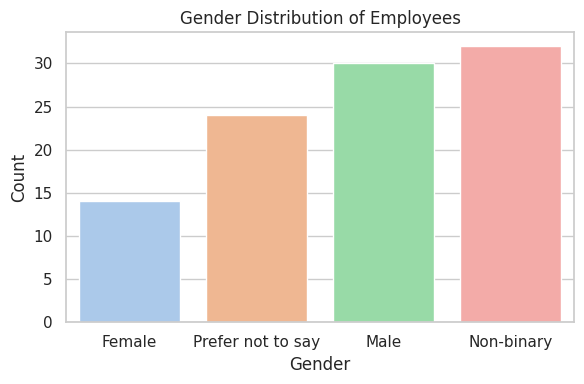

In [12]:
# Set plot style
sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))

# 1. Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Distribution of Employees')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


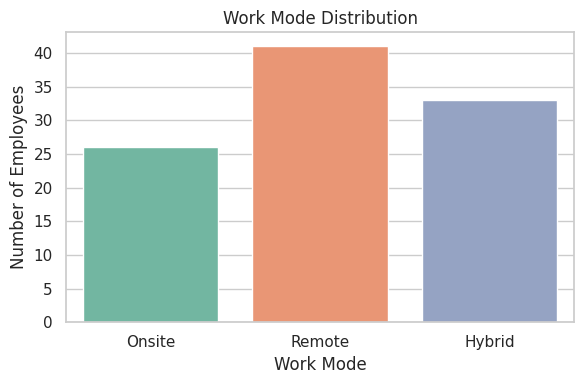

In [13]:
# 2. Work Mode Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Work_Mode', data=df, palette='Set2')
plt.title('Work Mode Distribution')
plt.xlabel('Work Mode')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

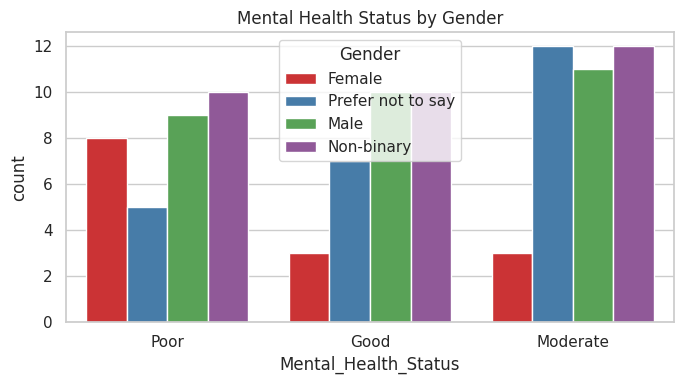

In [14]:
# 3. Mental Health Status by Gender
plt.figure(figsize=(7,4))
sns.countplot(x='Mental_Health_Status', hue='Gender', data=df, palette='Set1')
plt.title('Mental Health Status by Gender')
plt.tight_layout()
plt.show()


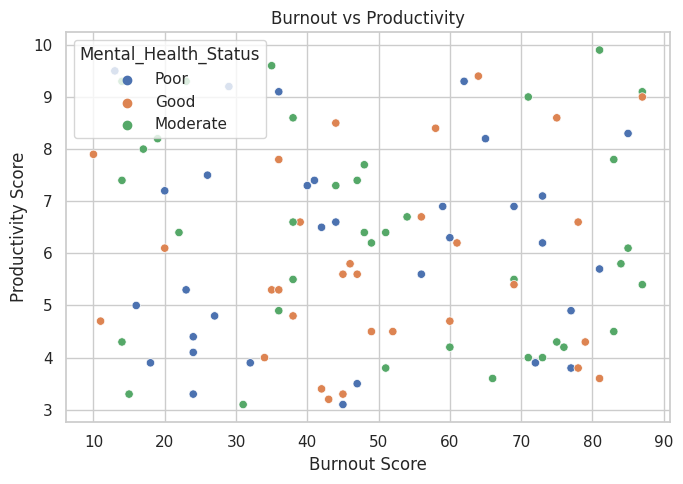

In [15]:
# 4. Burnout Score vs Productivity Score
plt.figure(figsize=(7,5))
sns.scatterplot(x='Burnout_Score', y='Productivity_Score', hue='Mental_Health_Status', data=df)
plt.title('Burnout vs Productivity')
plt.xlabel('Burnout Score')
plt.ylabel('Productivity Score')
plt.tight_layout()
plt.show()

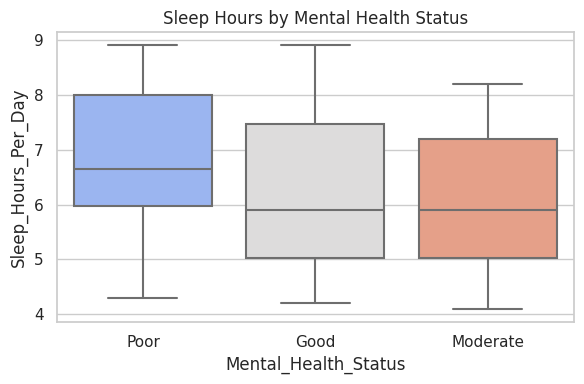

In [16]:
# 5. Average Sleep Hours per Mental Health Status
plt.figure(figsize=(6,4))
sns.boxplot(x='Mental_Health_Status', y='Sleep_Hours_Per_Day', data=df, palette='coolwarm')
plt.title('Sleep Hours by Mental Health Status')
plt.tight_layout()
plt.show()

In [17]:
# Define ordinal mapping
issue_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3,
    'Always': 4
}

# Apply mapping
df['Internet_Issues_Frequency'] = df['Internet_Issues_Frequency'].map(issue_map)

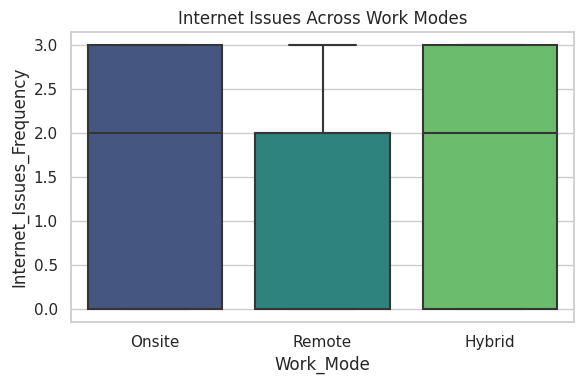

In [18]:
# 6. Internet Issues Frequency by Work Mode
plt.figure(figsize=(6,4))
sns.boxplot(x='Work_Mode', y='Internet_Issues_Frequency', data=df, palette='viridis')
plt.title('Internet Issues Across Work Modes')
plt.tight_layout()
plt.show()

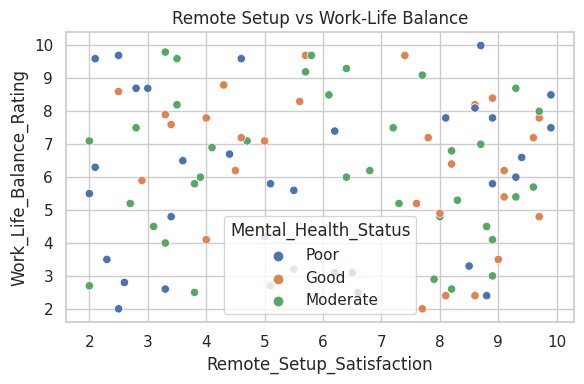

In [19]:
# 7. Remote Setup Satisfaction vs Work-Life Balance
plt.figure(figsize=(6,4))
sns.scatterplot(x='Remote_Setup_Satisfaction', y='Work_Life_Balance_Rating', hue='Mental_Health_Status', data=df)
plt.title('Remote Setup vs Work-Life Balance')
plt.tight_layout()
plt.show()

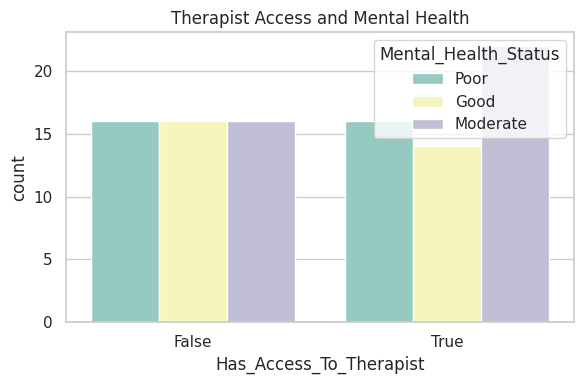

In [20]:
# 8. Access to Therapist by Mental Health Status
plt.figure(figsize=(6,4))
sns.countplot(x='Has_Access_To_Therapist', hue='Mental_Health_Status', data=df, palette='Set3')
plt.title('Therapist Access and Mental Health')
plt.tight_layout()
plt.show()

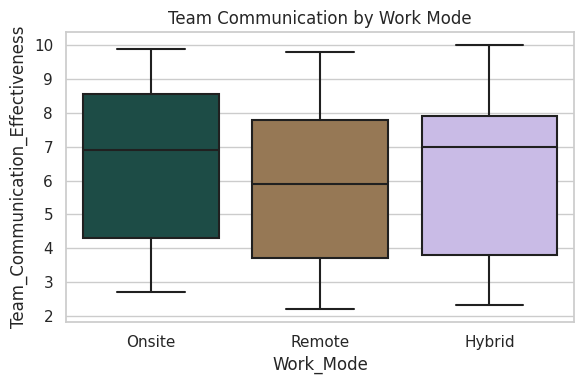

In [21]:
# 9. Team Communication Effectiveness by Work Mode
plt.figure(figsize=(6,4))
sns.boxplot(x='Work_Mode', y='Team_Communication_Effectiveness', data=df, palette='cubehelix')
plt.title('Team Communication by Work Mode')
plt.tight_layout()
plt.show()

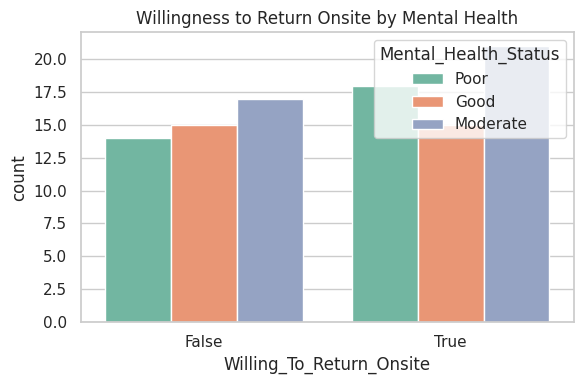

In [22]:
# 10. Willingness to Return Onsite vs Mental Health Status
plt.figure(figsize=(6,4))
sns.countplot(x='Willing_To_Return_Onsite', hue='Mental_Health_Status', data=df, palette='Set2')
plt.title('Willingness to Return Onsite by Mental Health')
plt.tight_layout()
plt.show()

## Predictive modeling

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


In [24]:
# Drop irrelevant columns
df.drop(['Employee_ID', 'Name'], axis=1, inplace=True)

# Handle missing values (if any)
df.dropna(inplace=True)

# Separate features and target
X = df.drop('Mental_Health_Status', axis=1)
y = df['Mental_Health_Status']

# Label encode all categorical features
le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

# Encode target if it's categorical
if y.dtype == 'object':
    y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Initialize all models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Train & Evaluate all models
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100
    accuracy_results[name] = round(accuracy, 2)

# Show accuracy results
print("Model Accuracy Scores (on Test Set):")
for name, acc in accuracy_results.items():
    print(f"{name}: {acc}%")

Model Accuracy Scores (on Test Set):
Logistic Regression: 20.0%
Decision Tree: 35.0%
Random Forest: 20.0%
Support Vector Machine: 35.0%
Naive Bayes: 15.0%
K-Nearest Neighbors: 25.0%


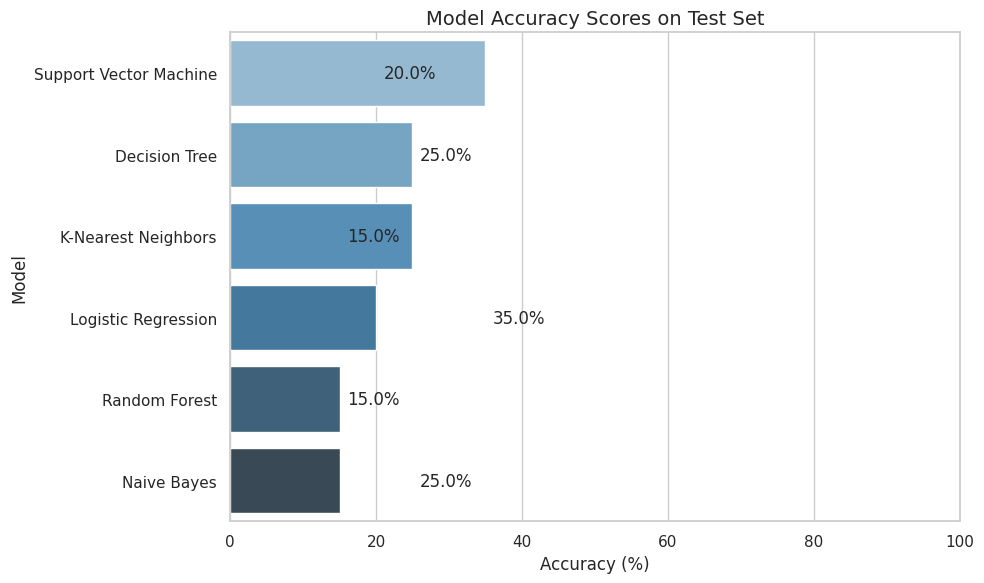

In [26]:
# Accuracy results dictionary
accuracy_results = {
    "Logistic Regression": 20.0,
    "Decision Tree": 25.0,
    "Random Forest": 15.0,
    "Support Vector Machine": 35.0,
    "Naive Bayes": 15.0,
    "K-Nearest Neighbors": 25.0
}

# Convert to DataFrame for easy plotting
import pandas as pd
acc_df = pd.DataFrame(list(accuracy_results.items()), columns=["Model", "Accuracy"])

# Sort values (optional)
acc_df = acc_df.sort_values(by='Accuracy', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=acc_df, x='Accuracy', y='Model', palette='Blues_d')
plt.title('Model Accuracy Scores on Test Set', fontsize=14)
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.xlim(0, 100)
for index, row in acc_df.iterrows():
    plt.text(row['Accuracy'] + 1, index, f"{row['Accuracy']}%", va='center')
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!